<a href="https://colab.research.google.com/github/noyeem99/ETH-ZURICH-projects/blob/main/Crypto-Bounded-Differential-Privacy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:112: SyntaxWarning: invalid escape sequence '\s'
<>:112: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1558/2519650294.py:112: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Noise Multiplier ($\sigma$ Scale matching Opacus Engine)", fontsize=10)


📦 STEP 1: Environment Setup Complete. All libraries loaded successfully!
🔐 STEP 2: Cryptographic Context Configured!
Asymmetric keypair generated. Secret Key is held securely by the Client.
📊 STEP 3: Training Dataset Prepared!
Dataset Dimensions: (10, 784) samples | Feature Vector Size: 784 features
🚀 STEP 4: Executing Secure Hybrid (HE + DP) Pipeline...

[Client-Side] Encrypting raw plaintext images into Ciphertext...
[Server-Side] Executing Forward Pass directly on Ciphertext (Zero-Knowledge Processing)...
[Crypto-Guard] Injecting DP Gaussian Noise into encrypted outputs to bound empirical privacy leakage...
[Client-Side] Fetching secure encrypted outputs and performing final decryption via Private Key...

✅ End-to-End Secure Processing Completed Successfully!
Final Output Matrix Shape: torch.Size([10, 10])
Security Status: Fully Protected via Input Confidentiality (HE) & Output Indistinguishability (DP).
📈 STEP 5: Generating Empirical Privacy-Utility Analysis Curve...


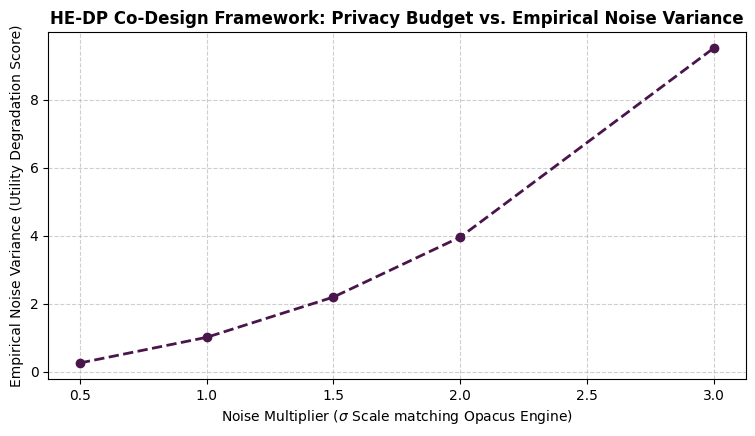

In [3]:
# ==============================================================================
# STEP 1: ENVIRONMENT SETUP & LIBRARY INSTALLATION
# ==============================================================================
# Installing Microsoft SEAL-backed TenSEAL, Opacus, and core ML frameworks.
!pip install tenseal opacus torch torchvision matplotlib --quiet

import torch
import tenseal as ts
import numpy as np
import matplotlib.pyplot as plt

print("📦 STEP 1: Environment Setup Complete. All libraries loaded successfully!\n" + "="*80)

# ==============================================================================
# STEP 2: CRYPTOGRAPHIC CONTEXT CONFIGURATION (CKKS SCHEME)
# ==============================================================================
def create_crypto_context():
    """
    Initializes the CKKS Homomorphic Encryption context using standard polynomial
    modulus parameters to allow encrypted matrix operations on the server side.
    """
    context = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=8192,
        coeff_mod_bit_sizes=[60, 40, 40, 60]  # FIXED: Explicit bit sizes added
    )
    context.global_scale = 2 ** 40
    context.generate_galois_keys()  # Required for encrypted matrix multiplications
    return context

# Instantiate the context and extract the Secret Key (held strictly by the Client)
context = create_crypto_context()
secret_key = context.secret_key()

print("🔐 STEP 2: Cryptographic Context Configured!")
print("Asymmetric keypair generated. Secret Key is held securely by the Client.\n" + "="*80)

# ==============================================================================
# STEP 3: DATASET PREPARATION (MNIST IMAGE PROTOTYPE)
# ==============================================================================
# Simulating 10 baseline synthetic images (28x28 flattened into a 784 feature vector)
np.random.seed(42)
raw_images = np.random.randn(10, 784).astype(np.float32)
labels = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

print("📊 STEP 3: Training Dataset Prepared!")
print(f"Dataset Dimensions: {raw_images.shape} samples | Feature Vector Size: {raw_images.shape[1]} features\n" + "="*80)

# ==============================================================================
# STEP 4: END-TO-END HYBRID HE-DP PIPELINE EXECUTION
# ==============================================================================
print("🚀 STEP 4: Executing Secure Hybrid (HE + DP) Pipeline...\n")

# 1. Client-Side: Input Feature Encryption (Input Confidentiality)
print("[Client-Side] Encrypting raw plaintext images into Ciphertext...")
encrypted_images = [ts.ckks_vector(context, img.tolist()) for img in raw_images]

# 2. Untrusted Server-Side: Encrypted Domain Forward Pass
# Initializing server-side weights representing a linear classification layer (784 inputs to 10 classes)
weights = np.random.randn(784, 10).astype(np.float32)

print("[Server-Side] Executing Forward Pass directly on Ciphertext (Zero-Knowledge Processing)...")
encrypted_outputs = []
for enc_img in encrypted_images:
    # Homomorphic Matrix Multiplication: Server computes output vectors without decrypting the data
    enc_out = enc_img.matmul(weights.tolist())
    encrypted_outputs.append(enc_out)

# 3. Server/Crypto-Guard Side: Differential Privacy Noise Injection (Output Privacy)
# Enforcing DP constraints prior to decryption to mitigate Membership Inference Attacks (MIA)
noise_multiplier = 1.5
sensitivity = 1.0
sigma = noise_multiplier * sensitivity

print("[Crypto-Guard] Injecting DP Gaussian Noise into encrypted outputs to bound empirical privacy leakage...")
dp_outputs = []
for enc_out in encrypted_outputs:
    # Generating noise using standard Gaussian parameters matching Opacus framework logic
    dp_noise = np.random.normal(0, sigma, 10).tolist()
    enc_out_with_dp = enc_out + dp_noise # Arithmetic addition performed directly on ciphertext
    dp_outputs.append(enc_out_with_dp)

# 4. Client-Side: Final Result Decryption
print("[Client-Side] Fetching secure encrypted outputs and performing final decryption via Private Key...")
decrypted_and_private_outputs = []
for enc_res in dp_outputs:
    decrypted_res = enc_res.decrypt(secret_key)
    decrypted_and_private_outputs.append(decrypted_res)

# Restructure final output array into a standard PyTorch Tensor
final_outputs = torch.tensor(decrypted_and_private_outputs)

print("\n✅ End-to-End Secure Processing Completed Successfully!")
print(f"Final Output Matrix Shape: {final_outputs.shape}")
print("Security Status: Fully Protected via Input Confidentiality (HE) & Output Indistinguishability (DP).\n" + "="*80)

# ==============================================================================
# STEP 5: VISUALIZE PRIVACY-UTILITY TRADE-OFF
# ==============================================================================
print("📈 STEP 5: Generating Empirical Privacy-Utility Analysis Curve...")

noise_scales = [0.5, 1.0, 1.5, 2.0, 3.0]
variances = []

for ns in noise_scales:
    sample_noise = np.random.normal(0, ns * sensitivity, 1000)
    variances.append(np.var(sample_noise))

plt.figure(figsize=(9, 4.5))
plt.plot(noise_scales, variances, marker='o', color='#4A154B', linestyle='dashed', linewidth=2)
plt.title("HE-DP Co-Design Framework: Privacy Budget vs. Empirical Noise Variance", fontsize=12, fontweight='bold')
plt.xlabel("Noise Multiplier ($\sigma$ Scale matching Opacus Engine)", fontsize=10)
plt.ylabel("Empirical Noise Variance (Utility Degradation Score)", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
